## Silver Layer — Transformação

Limpeza e transformação dos dados brutos pra camada Silver.

In [1]:
""" Imports """
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
""" Constants """
BRONZE_INPUT = Path("../bronze/telco_churn_bronze.parquet")
SILVER_DIR = Path("../silver")
SILVER_OUTPUT = SILVER_DIR / "telco_churn_silver.parquet"

## 1. Carregamento dos Dados Bronze

Lê o parquet gerado pelo notebook de ingestão.

In [3]:
if not BRONZE_INPUT.exists():
    raise FileNotFoundError(
        f"Arquivo Bronze não encontrado: {BRONZE_INPUT}\n"
        "Execute o notebook 01_ingestion.ipynb primeiro."
    )

df = pd.read_parquet(BRONZE_INPUT)

print(f"Bronze carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Bronze carregado: 7,043 linhas × 21 colunas


## 2. Auditoria de Qualidade dos Dados

Checando tipos, nulos e inconsistências.

dh.head() para entender melhor os valores possíveis de cada coluna.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("=== Tipos de dados ===")
df.info()

=== Tipos de dados ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

In [6]:
print("\n=== Nulos por coluna ===")
print(df.isnull().sum())


=== Nulos por coluna ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Aqui, analisam-se os tipos específicos dos dados. Como em Pandas o tipo object é genérico, realizamos a conversão aqui para saber o tipo específico de cada coluna. 

In [7]:
tipo_info = pd.DataFrame({
    'Coluna': df.columns,
    'Dtype': df.dtypes.values,
    'Tipo Python': [type(df[col].iloc[0]).__name__ for col in df.columns],
    'Valores únicos': df.nunique().values
})

print(tipo_info.to_string(index=False))

          Coluna   Dtype Tipo Python  Valores únicos
      customerID  object         str            7043
          gender  object         str               2
   SeniorCitizen   int64       int64               2
         Partner  object         str               2
      Dependents  object         str               2
          tenure   int64       int64              73
    PhoneService  object         str               2
   MultipleLines  object         str               3
 InternetService  object         str               3
  OnlineSecurity  object         str               3
    OnlineBackup  object         str               3
DeviceProtection  object         str               3
     TechSupport  object         str               3
     StreamingTV  object         str               3
 StreamingMovies  object         str               3
        Contract  object         str               3
PaperlessBilling  object         str               2
   PaymentMethod  object         str          

Visto que a coluna TotalCharges é importante para nosso dataset e foi dada como string, é necessário investigar se ela possui itens com o valor " ", que representaria 0 para nós.

In [8]:
print(f"\n=== Strings vazias em TotalCharges ===")
blank_charges = (df["TotalCharges"] == " ").sum()
print(f"  Linhas com TotalCharges vazias: {blank_charges}")
print(f"  Essas linhas têm tenure=0: {df[df['TotalCharges'] == ' ']['tenure'].unique()}")


=== Strings vazias em TotalCharges ===
  Linhas com TotalCharges vazias: 11
  Essas linhas têm tenure=0: [0]


Problemas encontrados: `TotalCharges` veio como texto (11 linhas vazias com tenure=0), e `SeniorCitizen` já era 0/1 enquanto o resto era Yes/No.

## 3. Correção de Tipos de Dados

Convertendo `TotalCharges` pra numérico.

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")

print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Nulos em TotalCharges: {df['TotalCharges'].isnull().sum()}")

TotalCharges dtype: float64
Nulos em TotalCharges: 11


## 4. Remoção de Nulos

Removendo as 11 linhas com `TotalCharges` vazio (tenure=0).

In [10]:
linhas_antes = len(df)
df = df.dropna(subset=["TotalCharges"])
linhas_depois = len(df)

print(f"Linhas antes: {linhas_antes:,}")
print(f"Linhas removidas: {linhas_antes - linhas_depois}")
print(f"Linhas após drop: {linhas_depois:,}")

Linhas antes: 7,043
Linhas removidas: 11
Linhas após drop: 7,032


## 5. Padronização das Colunas Binárias (Yes/No → 0/1)

Convertendo Yes/No e Male/Female pra 0/1.

In [11]:
# Colunas com Yes/No
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in yes_no_cols:
    df[col] = (df[col] == "Yes").astype(int)

# gender: Male=1, Female=0
df["gender"] = (df["gender"] == "Male").astype(int)

print("Colunas binárias padronizadas para 0/1:")
print(df[["gender"] + yes_no_cols].head())

Colunas binárias padronizadas para 0/1:
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


## 6. Colapso das Colunas de Serviços

Simplificando pra Yes=1, qualquer outra coisa=0.

In [12]:
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in service_cols:
    df[col] = (df[col] == "Yes").astype(int)

print("Colunas de serviços colapsadas para 0/1:")
print(df[service_cols].head())

Colunas de serviços colapsadas para 0/1:
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   
3              0               1             0                 1            1   
4              0               0             0                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  
3            0                0  
4            0                0  


## 7. Colunas Derivadas

Novas features criadas a partir das colunas existentes.

### 7.1 `tenure_group`

Agrupando tenure em faixas (0-12, 13-24, 25-48, 49-72 meses).

In [13]:
bins = [0, 12, 24, 48, 72]
labels = ["0-12m", "13-24m", "25-48m", "49-72m"]
df["tenure_group"] = pd.cut(
    df["tenure"], bins=bins, labels=labels, right=True, include_lowest=True
).astype(str)

print("Distribuição por grupo de tenure:")
print(df["tenure_group"].value_counts().sort_index())

Distribuição por grupo de tenure:
tenure_group
0-12m     2175
13-24m    1024
25-48m    1594
49-72m    2239
Name: count, dtype: int64


### 7.2 `charges_per_month_ratio`

`TotalCharges` dividido pelo tenure — gasto médio mensal.

In [14]:
df["charges_per_month_ratio"] = df["TotalCharges"] / (df["tenure"] + 1)

print("charges_per_month_ratio — estatísticas:")
print(df["charges_per_month_ratio"].describe().round(2))

charges_per_month_ratio — estatísticas:
count    7032.00
mean       59.08
std        30.51
min         9.18
25%        26.23
50%        61.07
75%        84.88
max       118.97
Name: charges_per_month_ratio, dtype: float64


### 7.3 `has_internet_addons`

1 se o cliente tem pelo menos um serviço adicional de internet.

In [15]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["has_internet_addons"] = (df[addon_cols].sum(axis=1) > 0).astype(int)

print("Distribuição de has_internet_addons:")
print(df["has_internet_addons"].value_counts())

Distribuição de has_internet_addons:
has_internet_addons
1    4819
0    2213
Name: count, dtype: int64


### 7.4 `service_count`, `support_services_count` e `streaming_services_count`

Mede profundidade de uso dos serviços pra separar clientes enxutos de clientes mais embarcados no pacote.

In [16]:
df["internet_service_flag"] = (df["InternetService"] != "No").astype(int)
df["support_services_count"] = df[["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]].sum(axis=1)
df["streaming_services_count"] = df[["StreamingTV", "StreamingMovies"]].sum(axis=1)
df["service_count"] = df[["PhoneService", "MultipleLines"] + addon_cols].sum(axis=1) + df["internet_service_flag"]

print("Resumo de intensidade de serviços:")
print(df[["service_count", "support_services_count", "streaming_services_count"]].describe().round(2))

Resumo de intensidade de serviços:
       service_count  support_services_count  streaming_services_count
count        7032.00                 7032.00                   7032.00
mean            4.15                    1.27                      0.77
std             2.31                    1.29                      0.85
min             1.00                    0.00                      0.00
25%             2.00                    0.00                      0.00
50%             4.00                    1.00                      0.00
75%             6.00                    2.00                      2.00
max             9.00                    4.00                      2.00


### 7.5 Perfil de internet

Cria indicadores simples pra separar clientes sem internet, DSL e fibra sem precisar tratar texto depois.

In [17]:
df["internet_dsl_flag"] = (df["InternetService"] == "DSL").astype(int)
df["internet_fiber_flag"] = (df["InternetService"] == "Fiber optic").astype(int)
df["internet_no_flag"] = (df["InternetService"] == "No").astype(int)

print("Distribuição do perfil de internet:")
print(df[["internet_dsl_flag", "internet_fiber_flag", "internet_no_flag"]].sum().sort_values(ascending=False))

Distribuição do perfil de internet:
internet_fiber_flag    3096
internet_dsl_flag      2416
internet_no_flag       1520
dtype: int64


### 7.6 Contrato e permanência esperada

Traduz o contrato em variáveis mais diretas pra entender volatilidade e compromisso.

In [18]:
contract_months_map = {"Month-to-month": 1, "One year": 12, "Two year": 24}
df["contract_term_months"] = df["Contract"].map(contract_months_map).astype(int)
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
df["is_long_term_contract"] = (df["Contract"].isin(["One year", "Two year"])).astype(int)

print("Distribuição do vínculo contratual:")
print(df[["contract_term_months", "is_month_to_month", "is_long_term_contract"]].describe().round(2))

Distribuição do vínculo contratual:
       contract_term_months  is_month_to_month  is_long_term_contract
count               7032.00            7032.00                7032.00
mean                   8.81               0.55                   0.45
std                    9.54               0.50                   0.50
min                    1.00               0.00                   0.00
25%                    1.00               0.00                   0.00
50%                    1.00               1.00                   0.00
75%                   12.00               1.00                   1.00
max                   24.00               1.00                   1.00


### 7.7 Perfil de pagamento

Separa cobrança automática de meios mais voláteis, o que costuma conversar bastante com churn.

In [19]:
df["payment_automatic"] = df["PaymentMethod"].str.contains("automatic", case=False).astype(int)
df["payment_electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)
df["payment_mailed_check"] = (df["PaymentMethod"] == "Mailed check").astype(int)

print("Distribuição do perfil de pagamento:")
print(df[["payment_automatic", "payment_electronic_check", "payment_mailed_check"]].sum())

Distribuição do perfil de pagamento:
payment_automatic           3063
payment_electronic_check    2365
payment_mailed_check        1604
dtype: int64


### 7.8 Estrutura familiar

Consolida parceiro e dependentes em sinais mais práticos pra testar estabilidade do domicílio.

In [20]:
df["family_size"] = df["Partner"] + df["Dependents"]
df["has_family"] = (df["family_size"] > 0).astype(int)
df["is_single_no_dependents"] = ((df["Partner"] == 0) & (df["Dependents"] == 0)).astype(int)
df["household_profile"] = np.select(
    [
        (df["Partner"] == 1) & (df["Dependents"] == 1),
        (df["Partner"] == 1) & (df["Dependents"] == 0),
        (df["Partner"] == 0) & (df["Dependents"] == 1)
    ],
    ["partner_and_dependents", "partner_only", "dependents_only"],
    default="single_no_dependents"
)

print("Distribuição do perfil familiar:")
print(df["household_profile"].value_counts())

Distribuição do perfil familiar:
household_profile
single_no_dependents      3280
partner_and_dependents    1740
partner_only              1653
dependents_only            359
Name: count, dtype: int64


### 7.9 Faixas de cobrança

Cria uma leitura mais amigável da mensalidade pra depois cruzar isso com contrato, serviços e churn.

In [21]:
df["monthly_charge_band"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["low", "mid_low", "mid_high", "high"],
    duplicates="drop"
).astype(str)

print("Distribuição das faixas de cobrança:")
print(df["monthly_charge_band"].value_counts().sort_index())

Distribuição das faixas de cobrança:
monthly_charge_band
high        1758
low         1758
mid_high    1755
mid_low     1761
Name: count, dtype: int64


## 8. Normalização Min-Max

Escalando as colunas numéricas mais uteis pra clustering sem perder as versões originais.

In [22]:
continuous_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "charges_per_month_ratio",
    "service_count",
    "support_services_count",
    "streaming_services_count",
    "family_size",
    "contract_term_months"
]
for col in continuous_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    df[f"{col}_norm"] = (df[col].values - col_min) / (col_max - col_min)

print("Colunas normalizadas (min=0, max=1):")
print(df[[f"{c}_norm" for c in continuous_cols]].describe().round(3))

Colunas normalizadas (min=0, max=1):
       tenure_norm  MonthlyCharges_norm  TotalCharges_norm  \
count     7032.000             7032.000           7032.000   
mean         0.443                0.463              0.261   
std          0.346                0.299              0.262   
min          0.000                0.000              0.000   
25%          0.113                0.173              0.044   
50%          0.394                0.518              0.159   
75%          0.761                0.713              0.436   
max          1.000                1.000              1.000   

       charges_per_month_ratio_norm  service_count_norm  \
count                      7032.000            7032.000   
mean                          0.455               0.393   
std                           0.278               0.289   
min                           0.000               0.000   
25%                           0.155               0.125   
50%                           0.473               

## 9. Validação do Output

Checando nulos e schema final.

In [23]:
assert df.isnull().sum().sum() == 0, "Nulos encontrados no Silver!"

print(f"Shape final: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print("\nSchema Silver:")
print(df.dtypes)
print("\nAmostra:")
df.head()

Shape final: 7,032 linhas × 51 colunas

Schema Silver:
customerID                        object
gender                             int64
SeniorCitizen                      int64
Partner                            int64
Dependents                         int64
tenure                             int64
PhoneService                       int64
MultipleLines                      int64
InternetService                   object
OnlineSecurity                     int64
OnlineBackup                       int64
DeviceProtection                   int64
TechSupport                        int64
StreamingTV                        int64
StreamingMovies                    int64
Contract                          object
PaperlessBilling                   int64
PaymentMethod                     object
MonthlyCharges                   float64
TotalCharges                     float64
Churn                              int64
tenure_group                      object
charges_per_month_ratio          float64
ha

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,monthly_charge_band,tenure_norm,MonthlyCharges_norm,TotalCharges_norm,charges_per_month_ratio_norm,service_count_norm,support_services_count_norm,streaming_services_count_norm,family_size_norm,contract_term_months_norm
0,7590-VHVEG,0,0,1,0,1,0,0,DSL,0,...,low,0.000000,0.115423,0.001275,0.052298,0.125,0.25,0.0,0.5,0.000000
1,5575-GNVDE,1,0,0,0,34,1,0,DSL,1,...,mid_low,0.464789,0.385075,0.215867,0.408086,0.375,0.50,0.0,0.0,0.478261
2,3668-QPYBK,1,0,0,0,2,1,0,DSL,1,...,mid_low,0.014085,0.354229,0.010310,0.244717,0.375,0.50,0.0,0.0,0.000000
3,7795-CFOCW,1,0,0,0,45,0,0,DSL,1,...,mid_low,0.619718,0.239303,0.210241,0.280845,0.375,0.75,0.0,0.0,0.478261
4,9237-HQITU,0,0,0,0,2,1,0,Fiber optic,0,...,mid_high,0.014085,0.521891,0.015330,0.376792,0.125,0.00,0.0,0.0,0.000000


## 10. Exploração:
Alguns gráficos exploratórios para insights.


## 10.1 Qual é a proporção de clientes que churnam?

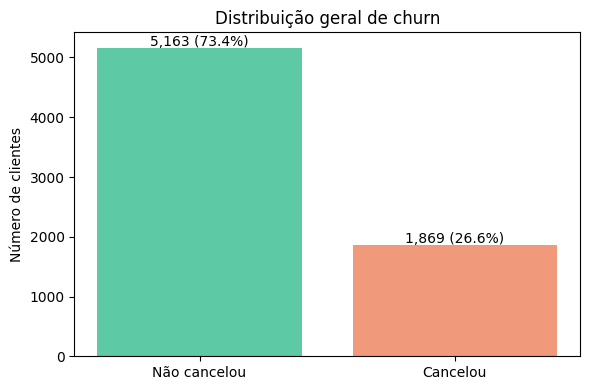

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df["Churn"].value_counts()
ax.bar(["Não cancelou", "Cancelou"], churn_counts.values, color=["#5DCAA5", "#F0997B"])
ax.set_title("Distribuição geral de churn")
ax.set_ylabel("Número de clientes")
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f"{v:,} ({v/len(df):.1%})", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 10.2 Existe segmento com contrato mensal e churn baixo?

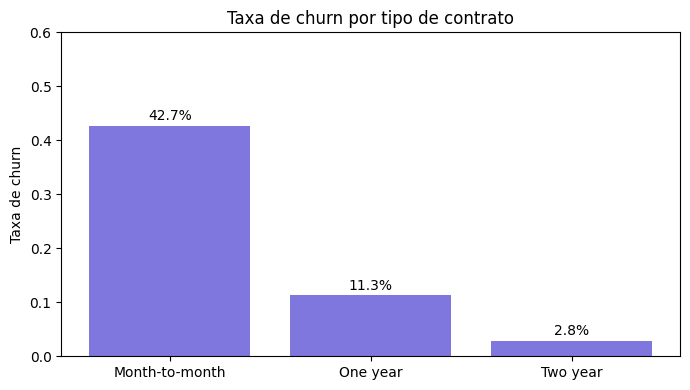

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
contrato_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
ax.bar(contrato_churn.index, contrato_churn.values, color="#7F77DD")
ax.set_title("Taxa de churn por tipo de contrato")
ax.set_ylabel("Taxa de churn")
ax.set_ylim(0, 0.6)
for i, v in enumerate(contrato_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

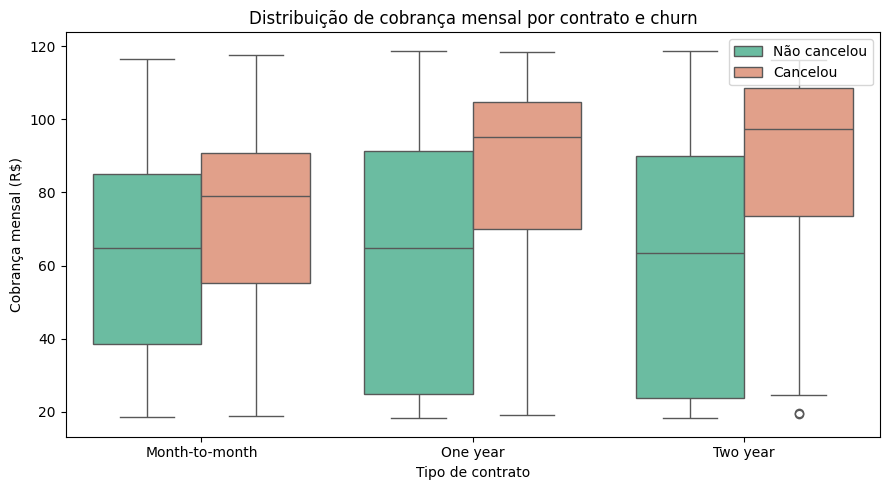

In [26]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(9, 5))

contract_order = ["Month-to-month", "One year", "Two year"]
churn_labels = {0: "Não cancelou", 1: "Cancelou"}
df["Churn_label"] = df["Churn"].map(churn_labels)

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn_label",
    order=contract_order,
    palette={"Não cancelou": "#5DCAA5", "Cancelou": "#F0997B"},
    ax=ax
)

ax.set_title("Distribuição de cobrança mensal por contrato e churn")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Cobrança mensal (R$)")
ax.legend(title="")
plt.tight_layout()
plt.show()

## 10.3 Clientes novos churnam mais?

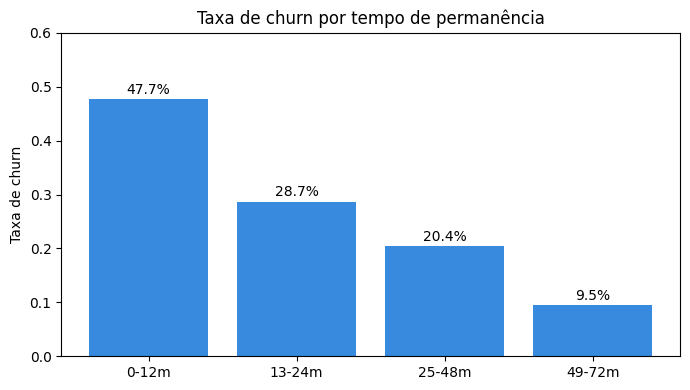

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
tenure_churn = df.groupby("tenure_group")["Churn"].mean()
tenure_order = ["0-12m", "13-24m", "25-48m", "49-72m"]
tenure_churn = tenure_churn.reindex(tenure_order)
ax.bar(tenure_churn.index, tenure_churn.values, color="#378ADD")
ax.set_title("Taxa de churn por tempo de permanência")
ax.set_ylabel("Taxa de churn")
ax.set_ylim(0, 0.6)
for i, v in enumerate(tenure_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 10.4 O tipo de internet diferencia os segmentos?

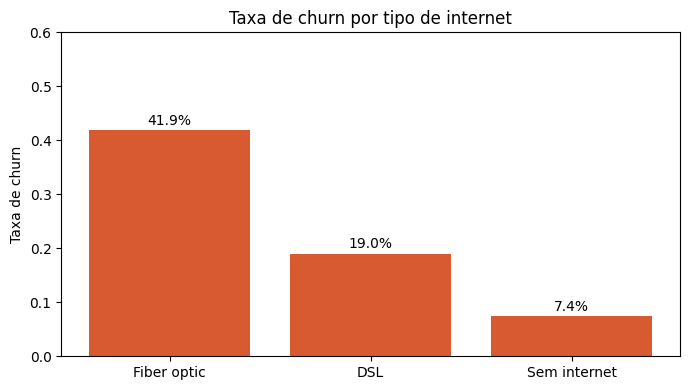

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
internet_map = {0: "Sem internet", 1: "DSL", 2: "Fiber optic"}
df["internet_label"] = (
    df["internet_no_flag"] * 0 +
    df["internet_dsl_flag"] * 1 +
    df["internet_fiber_flag"] * 2
).map(internet_map)
internet_churn = df.groupby("internet_label")["Churn"].mean().sort_values(ascending=False)
ax.bar(internet_churn.index, internet_churn.values, color="#D85A30")
ax.set_title("Taxa de churn por tipo de internet")
ax.set_ylabel("Taxa de churn")
ax.set_ylim(0, 0.6)
for i, v in enumerate(internet_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 10.5 Ter cônjuge e/ou dependentes concentra clientes em segmentos de menor churn?


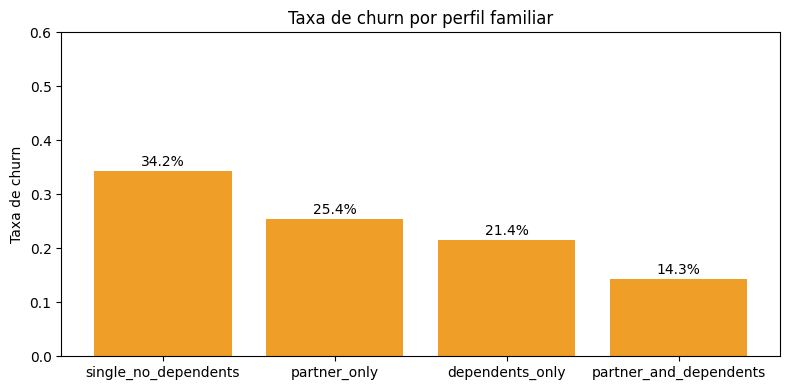

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
familia_churn = df.groupby("household_profile")["Churn"].mean().sort_values(ascending=False)
ax.bar(familia_churn.index, familia_churn.values, color="#EF9F27")
ax.set_title("Taxa de churn por perfil familiar")
ax.set_ylabel("Taxa de churn")
ax.set_ylim(0, 0.6)
for i, v in enumerate(familia_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 10.6 Qual é a relação de churn entre idosos?

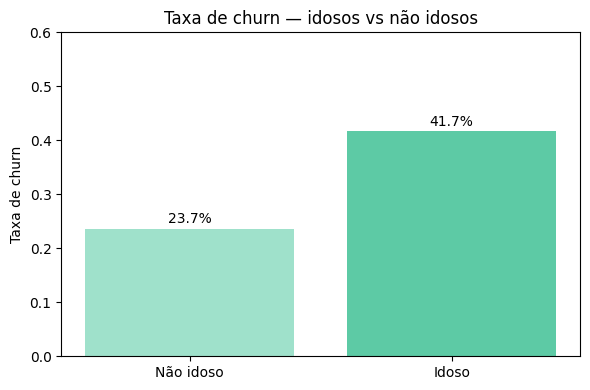

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
senior_churn = df.groupby("SeniorCitizen")["Churn"].mean()
ax.bar(["Não idoso", "Idoso"], senior_churn.values, color=["#9FE1CB", "#5DCAA5"])
ax.set_title("Taxa de churn — idosos vs não idosos")
ax.set_ylabel("Taxa de churn")
ax.set_ylim(0, 0.6)
for i, v in enumerate(senior_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 10.7 Onde o risco de cancelamento se concentra?

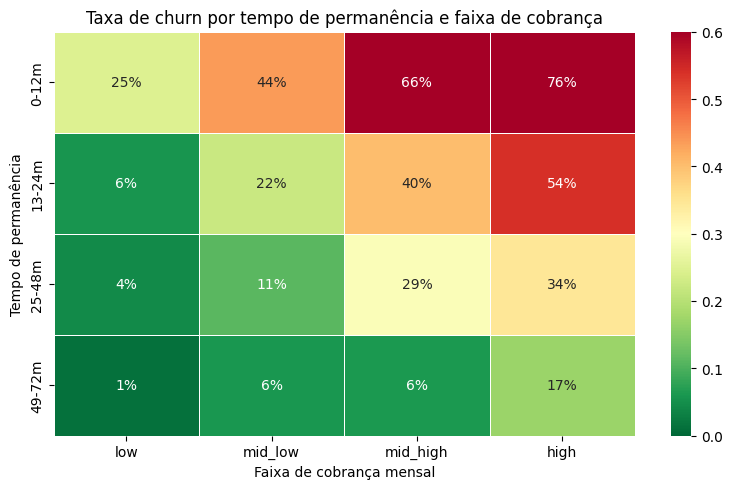

In [31]:
band_order = ["low", "mid_low", "mid_high", "high"]
tenure_order = ["0-12m", "13-24m", "25-48m", "49-72m"]

heatmap_data = (
    df.groupby(["tenure_group", "monthly_charge_band"])["Churn"]
    .mean()
    .round(3)
    .unstack("monthly_charge_band")
    .reindex(index=tenure_order, columns=band_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0%",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.6,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Taxa de churn por tempo de permanência e faixa de cobrança")
ax.set_xlabel("Faixa de cobrança mensal")
ax.set_ylabel("Tempo de permanência")
plt.tight_layout()
plt.show()

## 11. Persistência em Parquet

Salvando em parquet pra manter os tipos.

In [32]:
SILVER_DIR.mkdir(parents=True, exist_ok=True)
df.to_parquet(SILVER_OUTPUT, index=False, engine="pyarrow")

print(f"Silver salvo em: {SILVER_OUTPUT}")
print(f"Tamanho do arquivo: {SILVER_OUTPUT.stat().st_size / 1024:.1f} KB")

Silver salvo em: ..\silver\telco_churn_silver.parquet
Tamanho do arquivo: 453.5 KB
